In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
sns.set_theme(style="whitegrid")

In [21]:
df = pd.read_csv("student_habits_performance.csv")

In [24]:
target_col = 'Exam_Score'

In [27]:
cols_lower = {col.lower(): col for col in df.columns}
if target_col.lower() in cols_lower:
    target_col = cols_lower[target_col.lower()]
else:
    raise KeyError(f"Target column '{target_col}' not found in dataset.")

In [32]:
numeric_df = df.select_dtypes(include=[np.number]).dropna()

X = numeric_df.drop(columns=[target_col])
y = numeric_df[target_col]

print(f"\nTarget Column: '{target_col}'")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"Features list: {list(X.columns)}")


Target Column: 'exam_score'
Features (X) shape: (1000, 8)
Target (y) shape: (1000,)
Features list: ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating']


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [38]:
print(f"\nTraining Set Size: {X_train.shape[0]} samples")
print(f"Testing Set Size: {X_test.shape[0]} samples")


Training Set Size: 800 samples
Testing Set Size: 200 samples


In [42]:
model = LinearRegression()
model.fit(X_train, y_train)

coefficients_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("\n--- Model Coefficients ---")
print(coefficients_df.to_string(index=False))
print(f"Intercept: {model.intercept_:.4f}")



--- Model Coefficients ---
              Feature  Coefficient
  study_hours_per_day     9.533589
          sleep_hours     1.989896
 mental_health_rating     1.952032
   exercise_frequency     1.315593
attendance_percentage     0.145895
                  age     0.052559
        netflix_hours    -2.316592
   social_media_hours    -2.701878
Intercept: 5.9063


In [46]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)


print(f"Mean Absolute Error (MAE)     : {mae:.4f}")
print(f"Mean Squared Error (MSE)      : {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score                      : {r2:.4f}")


results_df = pd.DataFrame({
    'Actual Score': y_test.values,
    'Predicted Score': np.round(y_pred, 2),
    'Residual': np.round(y_test.values - y_pred, 2)
})

print(results_df.head(10))


Mean Absolute Error (MAE)     : 4.1302
Mean Squared Error (MSE)      : 25.9210
Root Mean Squared Error (RMSE): 5.0913
R² Score                      : 0.8989
   Actual Score  Predicted Score  Residual
0          64.2            66.05     -1.85
1          72.7            74.48     -1.78
2          79.0            78.10      0.90
3          79.5            74.38      5.12
4          58.2            61.42     -3.22
5          53.4            54.83     -1.43
6          70.8            75.92     -5.12
7          62.5            55.43      7.07
8          36.8            41.61     -4.81
9          67.6            72.82     -5.22


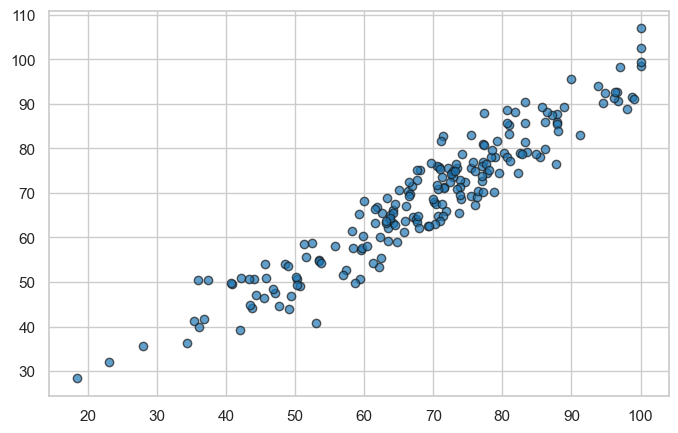

In [49]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='#1f77b4', alpha=0.7, edgecolors='k', label='Predictions')

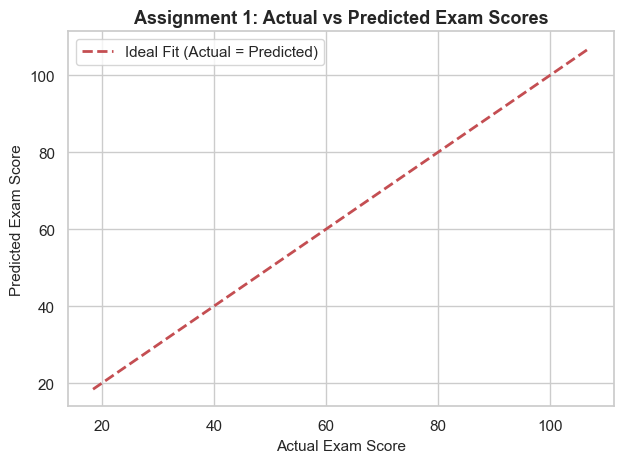

In [54]:
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal Fit (Actual = Predicted)')

plt.title('Assignment 1: Actual vs Predicted Exam Scores', fontsize=13, fontweight='bold')
plt.xlabel('Actual Exam Score', fontsize=11)
plt.ylabel('Predicted Exam Score', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()